# ☕ Detección de Enfermedades en Hojas de Café Arábica
## EDA + CNN Baseline — Dataset JMuBEN

**Dataset:** JMuBEN Coffee Dataset (Kaggle)  
**Link:** https://www.kaggle.com/datasets/noamaanabdulazeem/jmuben-coffee-dataset  
**Clases:** Healthy · Rust · Phoma · Cercospora · Miner  
**Total imágenes:** ~58,555  

**Objetivo del notebook:**
1. Realizar un EDA visual enfocado en Deep Learning
2. Implementar el modelo CNN básico del profesor
3. Evaluar si accuracy ≥ 90% → cambiar dataset

---
> **Impacto real:** Las enfermedades detectadas (roya, cercospora, minador, phoma) son
> las mismas que afectan los cafetales colombianos. Un MVP de esta solución podría
> beneficiar a los ~540,000 caficultores del país.

---
## 1. Importaciones y configuración global

In [17]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from sklearn.metrics import classification_report, confusion_matrix

# ────────────────────────────────────────────────────────────
DATA_DIR = '../Datasets'
# ─────────────────────────────────────────────────────────────────────────────


IMG_SIZE   = (64, 64)
BATCH_SIZE = 128
EPOCHS     = 3
SEED       = 42  

CLASS_COLORS = {
    'Healthy'    : '#2ecc71',
    'Rust'       : '#e67e22',
    'Phoma'      : '#9b59b6',
    'Cercospora' : '#e74c3c',
    'Miner'      : '#3498db'
}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'Dataset    : {os.path.abspath(DATA_DIR)}')

TensorFlow : 2.10.1
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset    : c:\Deep_Learning\JMuBEN\Datasets


---
## 2. EDA — Exploración del Dataset
### 2.1 Estructura y conteo por clase

In [18]:
VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')
class_counts = {}

print('Estructura del dataset:')
print('=' * 45)
for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTS)]
        class_counts[cls] = len(imgs)
        print(f'  {cls:<15} → {len(imgs):>7,} imágenes')

total    = sum(class_counts.values())
classes  = list(class_counts.keys())
n_classes = len(classes)
print('=' * 45)
print(f'  Clases         : {n_classes}')
print(f'  Total imágenes : {total:,}')
print(f'  Promedio/clase : {total // n_classes:,}')

Estructura del dataset:
  Cerscospora     →   7,681 imágenes
  Healthy         →  18,983 imágenes
  Leaf rust       →   8,336 imágenes
  Miner           →  16,978 imágenes
  Phoma           →   6,571 imágenes
  Clases         : 5
  Total imágenes : 58,549
  Promedio/clase : 11,709


### 2.2 Distribución de clases — ¿Está balanceado?

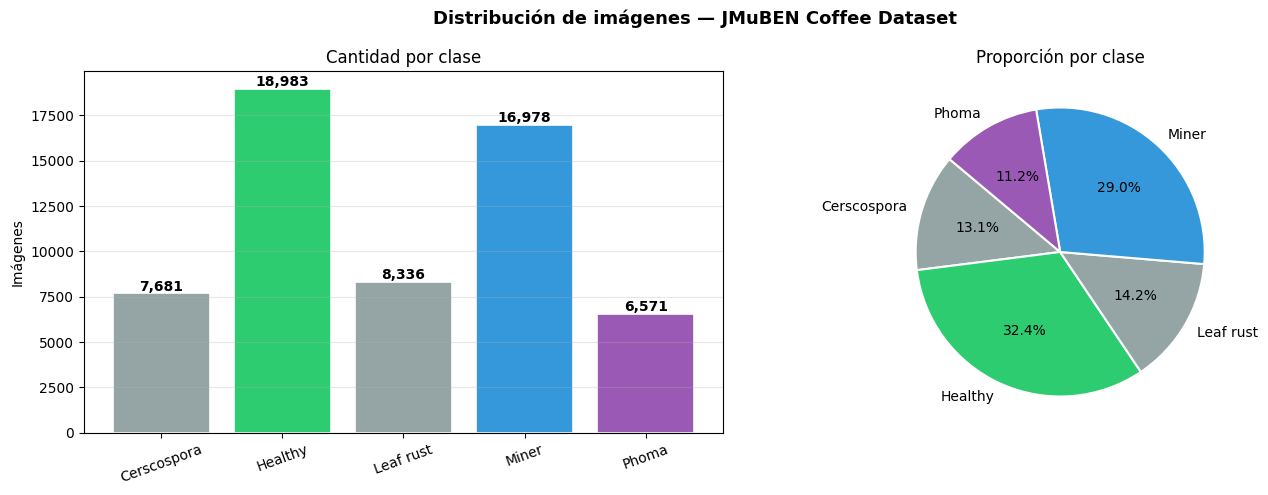

Ratio max/min: 2.89x
⚠️  Dataset MODERADAMENTE DESBALANCEADO


In [19]:
counts = list(class_counts.values())
colors = [CLASS_COLORS.get(c, '#95a5a6') for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de imágenes — JMuBEN Coffee Dataset',
             fontsize=13, fontweight='bold')

# Barras
bars = axes[0].bar(classes, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Cantidad por clase')
axes[0].set_ylabel('Imágenes')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{cnt:,}', ha='center', fontsize=10, fontweight='bold')

# Torta
wedges, texts, autotexts = axes[1].pie(
    counts, labels=classes, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.savefig('eda_01_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = max(counts) / min(counts)
print(f'Ratio max/min: {ratio:.2f}x')
if ratio < 2:
    print('✅ Dataset BALANCEADO')
elif ratio < 5:
    print('⚠️  Dataset MODERADAMENTE DESBALANCEADO')
else:
    print('🔴 Dataset MUY DESBALANCEADO — considerar class_weight')

### 2.3 Muestras visuales por clase

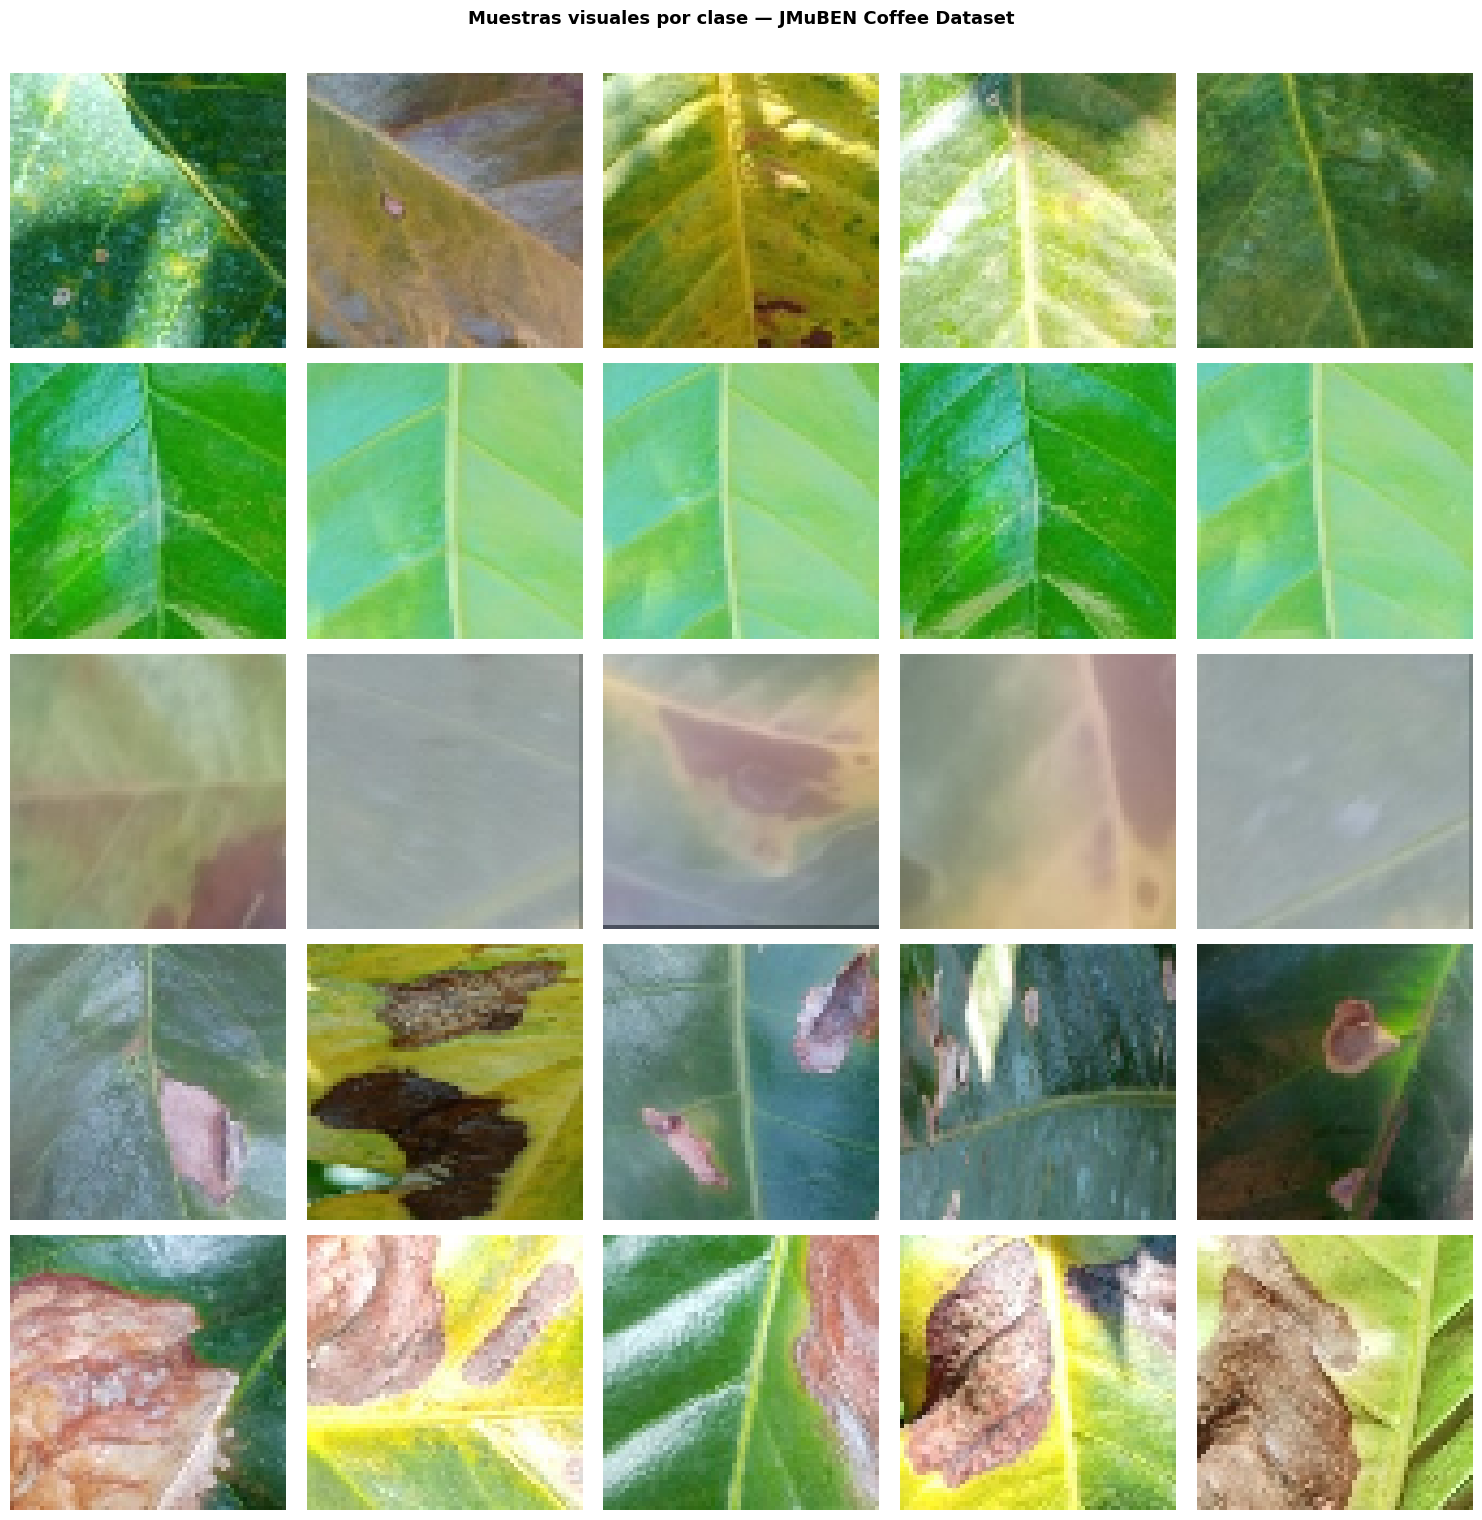

In [20]:
N_SAMPLES = 5
CLASS_DESC = {
    'Healthy'    : 'Hoja sana',
    'Rust'       : 'Roya — principal amenaza del café colombiano',
    'Phoma'      : 'Phoma — necrosis desde el borde de la hoja',
    'Cercospora' : 'Cercospora — manchas circulares gris-blanquecinas',
    'Miner'      : 'Minador — trayectorias amarillas de larvas'
}

fig, axes = plt.subplots(n_classes, N_SAMPLES,
                         figsize=(N_SAMPLES * 3, n_classes * 3))

for i, cls in enumerate(sorted(classes)):
    cls_path = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTS)]
    sample = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

    for j, img_name in enumerate(sample):
        img = load_img(os.path.join(cls_path, img_name), target_size=IMG_SIZE)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(
                f"{cls}\n{CLASS_DESC.get(cls, '')}",
                fontsize=8, fontweight='bold',
                color=CLASS_COLORS.get(cls, 'black'),
                rotation=0, labelpad=140, va='center'
            )

plt.suptitle('Muestras visuales por clase — JMuBEN Coffee Dataset',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_muestras.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Análisis de dimensiones originales

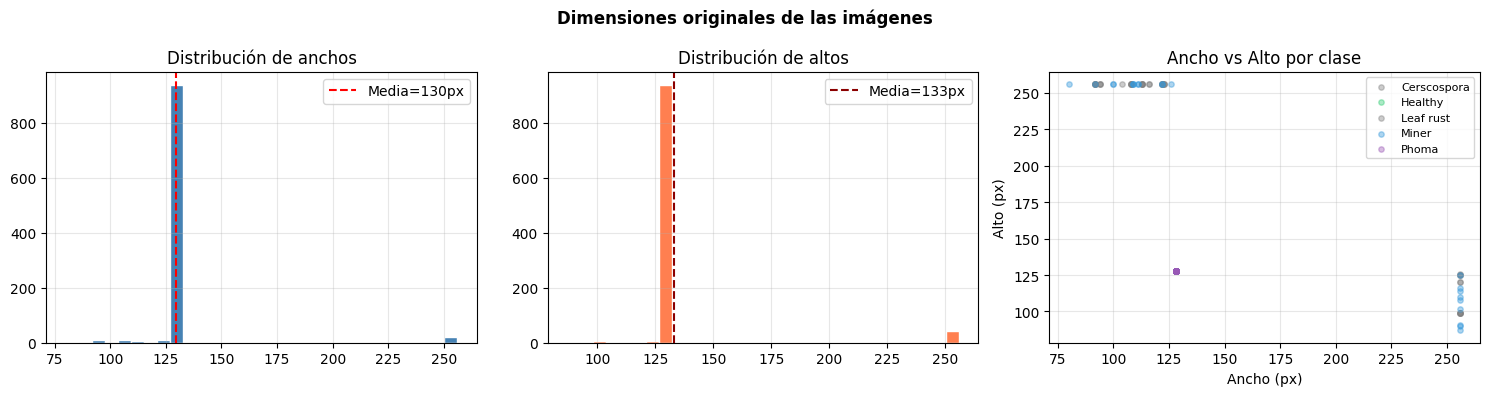

        ancho    alto
count  1000.0  1000.0
mean    130.0   133.0
std      19.0    26.0
min      80.0    87.0
25%     128.0   128.0
50%     128.0   128.0
75%     128.0   128.0
max     256.0   256.0

→ Se usará input_shape=(64, 64, 3) en el modelo (resize automático)


In [21]:
MAX_SAMPLE = 200
dim_data = []

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTS)]
    sample = random.sample(all_imgs, min(MAX_SAMPLE, len(all_imgs)))
    for img_name in sample:
        try:
            with Image.open(os.path.join(cls_path, img_name)) as im:
                w, h = im.size
                dim_data.append({'clase': cls, 'ancho': w, 'alto': h})
        except Exception:
            pass

df_dims = pd.DataFrame(dim_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dimensiones originales de las imágenes', fontsize=12, fontweight='bold')

axes[0].hist(df_dims['ancho'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_dims['ancho'].mean(), color='red', linestyle='--',
                label=f'Media={df_dims["ancho"].mean():.0f}px')
axes[0].set_title('Distribución de anchos')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_dims['alto'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_dims['alto'].mean(), color='darkred', linestyle='--',
                label=f'Media={df_dims["alto"].mean():.0f}px')
axes[1].set_title('Distribución de altos')
axes[1].legend(); axes[1].grid(alpha=0.3)

for cls in classes:
    sub = df_dims[df_dims['clase'] == cls]
    axes[2].scatter(sub['ancho'], sub['alto'],
                    color=CLASS_COLORS.get(cls, 'gray'),
                    label=cls, alpha=0.4, s=15)
axes[2].set_title('Ancho vs Alto por clase')
axes[2].set_xlabel('Ancho (px)'); axes[2].set_ylabel('Alto (px)')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_03_dimensiones.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_dims[['ancho', 'alto']].describe().round(0))
print(f'\n→ Se usará input_shape={IMG_SIZE + (3,)} en el modelo (resize automático)')

### 2.5 Distribución de canales RGB por clase

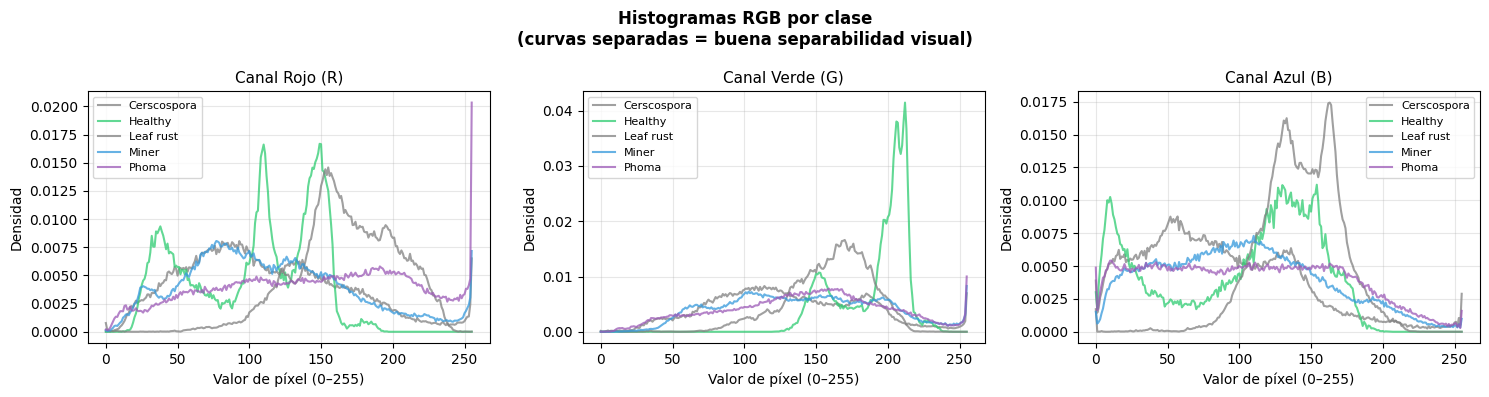

In [22]:
N_HIST = 60
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ch_names  = ['Canal Rojo (R)', 'Canal Verde (G)', 'Canal Azul (B)']

for ch_idx, ch_name in enumerate(ch_names):
    for cls in classes:
        cls_path = os.path.join(DATA_DIR, cls)
        all_imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(VALID_EXTS)]
        sample = random.sample(all_imgs, min(N_HIST, len(all_imgs)))

        hist_sum = np.zeros(256)
        for img_name in sample:
            try:
                arr = np.array(load_img(
                    os.path.join(cls_path, img_name), target_size=(64,64)
                ))
                h, _ = np.histogram(arr[:,:,ch_idx], bins=256, range=(0,256))
                hist_sum += h
            except Exception:
                pass

        axes[ch_idx].plot(
            hist_sum / hist_sum.sum(),
            color=CLASS_COLORS.get(cls, 'gray'),
            label=cls, alpha=0.75, linewidth=1.5
        )

    axes[ch_idx].set_title(ch_name, fontsize=11)
    axes[ch_idx].set_xlabel('Valor de píxel (0–255)')
    axes[ch_idx].set_ylabel('Densidad')
    axes[ch_idx].legend(fontsize=8)
    axes[ch_idx].grid(alpha=0.3)

fig.suptitle('Histogramas RGB por clase\n(curvas separadas = buena separabilidad visual)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Imagen promedio por clase (prototipo visual)

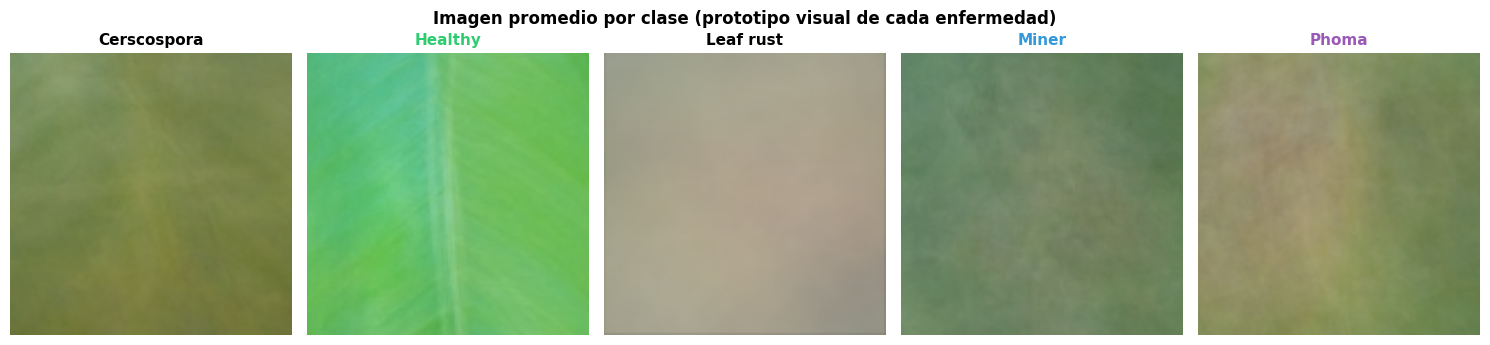

In [23]:
N_AVG  = 100
TARGET = (128, 128)

fig, axes = plt.subplots(1, n_classes, figsize=(n_classes * 3, 3.5))

for ax, cls in zip(axes, sorted(classes)):
    cls_path = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTS)]
    sample = random.sample(all_imgs, min(N_AVG, len(all_imgs)))

    stack = []
    for img_name in sample:
        try:
            arr = np.array(
                load_img(os.path.join(cls_path, img_name), target_size=TARGET),
                dtype=np.float32
            )
            stack.append(arr)
        except Exception:
            pass

    if stack:
        ax.imshow(np.mean(stack, axis=0).astype(np.uint8))
    ax.set_title(cls, fontweight='bold',
                 color=CLASS_COLORS.get(cls, 'black'), fontsize=11)
    ax.axis('off')

fig.suptitle('Imagen promedio por clase (prototipo visual de cada enfermedad)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_promedio.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Resumen ejecutivo del EDA

In [24]:
print('=' * 55)
print('       RESUMEN EDA — JMuBEN Coffee Dataset')
print('=' * 55)
print(f'  Clases          : {n_classes} ({", ".join(sorted(classes))})')
print(f'  Total imágenes  : {total:,}')
print(f'  Promedio/clase  : {total // n_classes:,}')
print(f'  Balance ratio   : {max(counts)/min(counts):.2f}x')
print(f'  Input al modelo : {IMG_SIZE[0]}x{IMG_SIZE[1]}x3')
print(f'  Datos reales    : ✅ 100% campo real')
print(f'  Sintéticos      : ❌ Ninguno')
print('=' * 55)
print('Relevancia para Colombia:')
print('  Rust       → Roya, devastó cafetales col. 2008-2012')
print('  Cercospora → Afecta calidad del grano exportado')
print('  Phoma      → Frecuente en zonas altas cafeteras')
print('  Miner      → Presente en todo el Eje Cafetero')
print('=' * 55)

       RESUMEN EDA — JMuBEN Coffee Dataset
  Clases          : 5 (Cerscospora, Healthy, Leaf rust, Miner, Phoma)
  Total imágenes  : 58,549
  Promedio/clase  : 11,709
  Balance ratio   : 2.89x
  Input al modelo : 64x64x3
  Datos reales    : ✅ 100% campo real
  Sintéticos      : ❌ Ninguno
Relevancia para Colombia:
  Rust       → Roya, devastó cafetales col. 2008-2012
  Cercospora → Afecta calidad del grano exportado
  Phoma      → Frecuente en zonas altas cafeteras
  Miner      → Presente en todo el Eje Cafetero


---
## 3. Preparación de datos
### 3.1 Generadores Train / Validación

In [25]:

import multiprocessing
WORKERS = multiprocessing.cpu_count() - 1  # usa todos los núcleos menos uno

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.80,   # usa solo 20% del dataset total
    rotation_range=10,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.80    # mismo split
)
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=256,          # más grande en val = menos pasos = más rápido
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f'Clases: {train_gen.class_indices}')
print(f'Train : {train_gen.samples:,} imágenes')
print(f'Val   : {val_gen.samples:,} imágenes')



SyntaxError: unmatched ')' (2975525688.py, line 12)

### 3.2 Visualización del augmentation

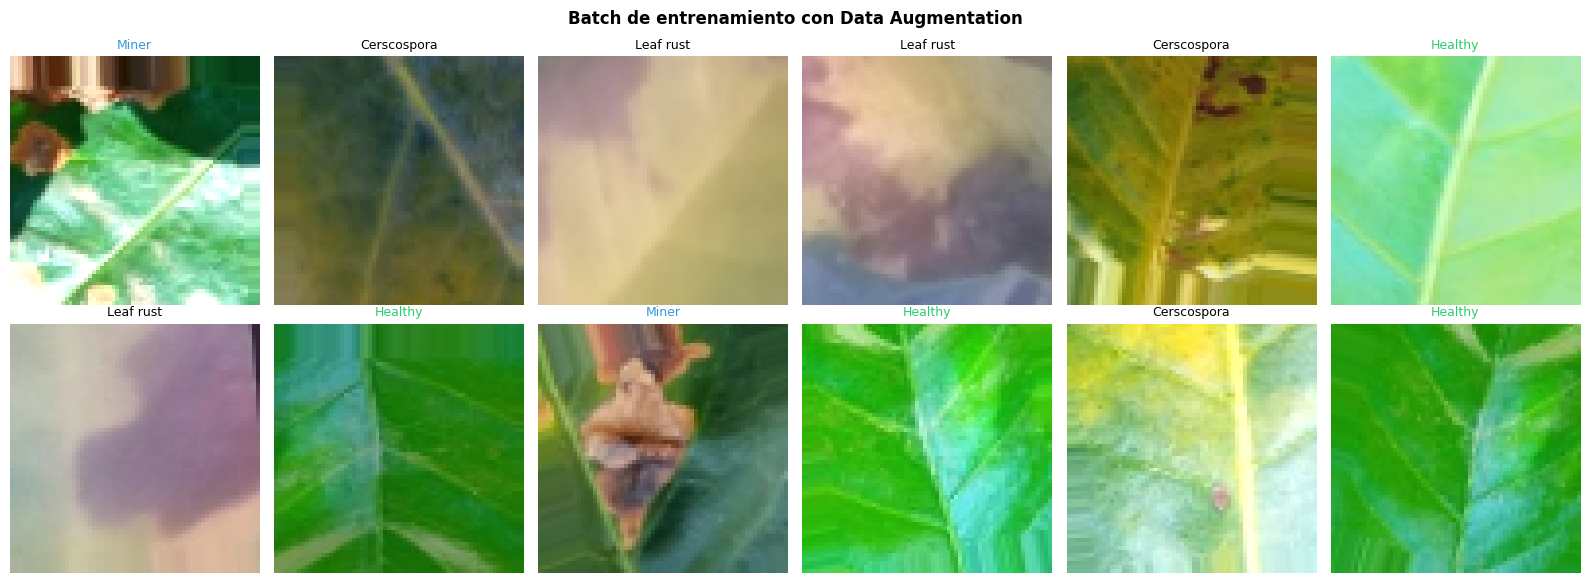

In [ ]:
batch_x, batch_y = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(batch_x): break
    ax.imshow(batch_x[i])
    label = class_names[np.argmax(batch_y[i])]
    ax.set_title(label, fontsize=9, color=CLASS_COLORS.get(label, 'black'))
    ax.axis('off')

fig.suptitle('Batch de entrenamiento con Data Augmentation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Modelo CNN Simple

In [ ]:
def build_solar_cnn(input_shape=(224, 224, 3), num_classes=5):
    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        # Bloque 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Bloque 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Flatten
        layers.Flatten(),

        # Fully connected
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_solar_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nParámetros totales: {model.count_params():,}')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 8, 8, 128)        0

---
## 5. Entrenamiento

In [ ]:
cb_list = [
        callbacks.EarlyStopping(
        patience=2,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        verbose=1, min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        'best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]


history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=cb_list,
    verbose=1
)


Epoch 1/3
366/366 [==============================] - 1102s 3s/step - loss: 0.1153 - accuracy: 0.9611 - val_loss: 0.0361 - val_accuracy: 0.9902 - lr: 0.0010
Epoch 2/3
366/366 [==============================] - 207s 565ms/step - loss: 0.0686 - accuracy: 0.9789 - val_loss: 0.0124 - val_accuracy: 0.9972 - lr: 0.0010
Epoch 3/3
366/366 [==============================] - 616s 2s/step - loss: 0.0473 - accuracy: 0.9851 - val_loss: 0.0078 - val_accuracy: 0.9981 - lr: 0.0010


: 

---
## 6. Curvas de aprendizaje

In [ ]:
epochs_ran = len(history.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de aprendizaje — CNN Básica (arquitectura del profesor)',
             fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validación', color='coral', linewidth=2)
axes[0].axhline(0.90, color='green', linestyle='--',
                linewidth=1.5, label='Umbral 90%')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validación', color='coral', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resultados_01_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnóstico overfitting
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f'Train accuracy final : {history.history["accuracy"][-1]*100:.2f}%')
print(f'Val accuracy final   : {history.history["val_accuracy"][-1]*100:.2f}%')
print(f'Gap (overfitting)    : {gap*100:.2f}%')
if gap > 0.15:
    print('⚠️  Overfitting significativo (gap > 15%)')
elif gap > 0.05:
    print('⚡ Overfitting moderado (5–15%)')
else:
    print('✅ Buen ajuste (gap < 5%)')

---
## 7. Evaluación final

In [ ]:
val_loss, val_acc = model.evaluate(val_gen, verbose=0)

print('\n' + '='*52)
print('        EVALUACIÓN FINAL EN VALIDACIÓN')
print('='*52)
print(f'  Val Loss     : {val_loss:.4f}')
print(f'  Val Accuracy : {val_acc*100:.2f}%')
print('='*52)

if val_acc >= 0.90:
    print('\n🔴 VEREDICTO: Accuracy ≥ 90%')
    print('   → Según el profesor: CAMBIAR DATASET')
else:
    print('\n🟢 VEREDICTO: Accuracy < 90%')
    print('   → El dataset es desafiante. Pueden continuar.')
    print('   → Siguiente paso: transfer learning (ResNet, EfficientNet)')

### 7.1 Matriz de confusión

In [ ]:
val_gen.reset()
y_pred  = np.argmax(model.predict(val_gen, verbose=1), axis=1)
y_true  = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matriz de Confusión', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
axes[0].set_title('Valores absolutos')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicción')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalizada (recall por clase)')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicción')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('resultados_02_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nReporte de clasificación:')
print(classification_report(y_true, y_pred, target_names=class_names))

### 7.2 Muestra de predicciones — ¿Dónde falla el modelo?

In [ ]:
val_gen.reset()
batch_x, batch_y = next(val_gen)
preds = model.predict(batch_x, verbose=0)

fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.suptitle('Predicciones del modelo (Verde=correcto · Rojo=error)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(batch_x):
        ax.axis('off'); continue
    real    = class_names[np.argmax(batch_y[i])]
    pred    = class_names[np.argmax(preds[i])]
    conf    = np.max(preds[i]) * 100
    correct = real == pred

    ax.imshow(batch_x[i])
    ax.set_title(f'Real: {real}\nPred: {pred} ({conf:.0f}%)',
                 color='green' if correct else 'red', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('green' if correct else 'red')
        spine.set_linewidth(3)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig('resultados_03_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Resumen del proyecto

| Aspecto | Valor |
|---|---|
| Dataset | JMuBEN Coffee Dataset |
| Imágenes | ~58,555 reales (100%) |
| Clases | Healthy · Rust · Phoma · Cercospora · Miner |
| Val Accuracy | *(ver celda 7)* |
| Impacto Colombia | Detección de roya y enfermedades en café arábica |

### Próximos pasos si accuracy < 90% ✅
- Transfer learning: ResNet50, EfficientNetB0, MobileNetV2
- Fine-tuning con fotos de cafetales colombianos
- MVP como app móvil (Streamlit / Flask)
- Alianza con Federación Nacional de Cafeteros / Cenicafé

### Referencia del dataset
> Jepkoech, J. et al. (2021). *Arabica coffee leaf images dataset.*  
> Data in Brief, 36, 107142. https://doi.org/10.1016/j.dib.2021.107142